In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
from scipy.special import comb
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import random
import string
import statsmodels.api as sm
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

from joblib import Parallel, delayed
from tqdm import tqdm

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

### Read in stories and recalls.

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [3]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

# print(story_processed_all[0])

print(recall_processed_all[3][0])   # clear clause of each participant.

[' it was their rookie year ', ' and the chiefs daughter took an interest in them. ', ' she said she was going to run away, ', ' the chief came to their house ', ' and they went to a place when her scarf was found. ', ' They ended up finding her at the police station. ', ' The chief advised them to transfer to another department ', ' as he never forgets. ', " that's what he did."]


In [4]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

In [5]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

print(additional_recall_processed[0][10])

['I met three friends in 1949 at college.', 'We had been to the same primary school but went to different high schools.', 'We had all been athletes, so bonded at college over this.', 'I had grown up on a farm but the other three guys were city folk.', 'They loved to come out to the farm and help with chores and to go hunting rabbits and squirrels and be in nature.', "I wasn't keen on hunting but wanted to be part of group and it made the guys happy.", 'After several years, the guys said they would love to go on a bear hunt and told everyone we were going.', "I didn't want to but went along with it.", 'We took a plane from Fort Wayne up to Canada and then canoes in to the North Woods, we had to back pack for 500 miles.', 'Finally we got to a cabin where we had had groceries and stuff delivered.', 'It was really spooky in the cabin and we were all spooked about going out day or night.', 'So we sat around playing cards and not being able to sleep.', "The others felt we would lose face if 

In [6]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
# print(len(story_processed_all))

recall_processed_all = recall_processed_all + additional_recall_processed
print(len(recall_processed_all[0]))

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses)

100
clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [7]:
# get data for clauses in the recalls.
recall_clauses = [[len(recall_processed_all[i][participant]) for participant in np.arange(len(recall_processed_all[i]))] 
                        for i in np.arange(len(recall_processed_all))]
print(recall_processed_all[0][0])
print(recall_clauses[0][0])

recall_clauses = [[item for item in recall_clauses[i] if item !=0 ] 
                        for i in np.arange(len(recall_clauses))]   # remove missing data in recall.

print(recall_clauses[0])

mean_recall_clauses = [round(np.mean(list_sub), 2) for list_sub in recall_clauses]
print(mean_recall_clauses)

[' Yeh, ', ' so I was in the boy scouts ', ' and we was doing the 50 yard dash. ', ' We was doing the 50 yard dash ', ' and two or three times in ', ' and I got the cramps. ', ' I started yelling for help ', ' but nobody believed me ', ' because they thought I was trying to catch up ', ' because I was slowing down. ', ' The scoutmaster was there ', ' and he paid me no attention. ', ' Then suddenly a man came up at that time ', ' and he grabbed me.']
14
[14, 9, 13, 10, 19, 9, 14, 7, 9, 7, 5, 8, 9, 13, 3, 12, 11, 13, 6, 20, 6, 17, 1, 13, 4, 17, 9, 8, 7, 18, 10, 21, 10, 7, 10, 13, 8, 9, 5, 6, 9, 10, 3, 14, 18, 10, 9, 10, 5, 5, 6, 7, 19, 14, 6, 8, 10, 10, 6, 6, 8, 5, 5, 9, 5, 9, 10, 9, 5, 15, 10, 15, 3, 14, 7, 10, 9, 11, 1, 9, 8, 13, 11, 6, 6, 13, 6, 7, 9, 3, 6, 13, 11, 7, 6, 7, 17, 3, 11, 7]
[9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]


### embed the stories and recalls

In [8]:
# embed for the first story.
model = SentenceTransformer('all-MiniLM-L6-v2')
story_emb_all = [model.encode(story) for story in story_processed_all]

recall_emb_all = [[model.encode(participant) for participant in story if len(participant) > 1]
                    for story in recall_processed_all]


In [9]:
clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
clause_recall = [9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]
compression_ratio = [item1/item2 for item1, item2 in zip(clause_recall, clause_story)]

### nonlinear effective dimension.

In [10]:
# calculate the covariance matrix with each data as the column and row.
def covariance_matrix(X):
    X_centered = X - np.mean(X, axis=0)
    
    d = X.shape[0]    # number of rows. used N-1, no matter how you get the cov matrix.
    cov = (X_centered.T @ X_centered) / (d - 1)     # 384x384 cov matrix.
    return cov

story_cov = [covariance_matrix(story_emb_all[story]) for story in np.arange(12)]
recall_cov = [[covariance_matrix(participant) for participant in story if len(participant) > 1]
                for story in recall_emb_all]

In [11]:
# calculate the distance matrix, for the shortest story 1.
def euclidean_distance_matrix(X):
    squared_norms = np.sum(X**2, axis=1).reshape(-1, 1)
    dist_sq = squared_norms + squared_norms.T - 2 * np.dot(X, X.T)
    np.maximum(dist_sq, 0, out=dist_sq)
    return np.sqrt(dist_sq)

def nonlinear_dimension_data(distance_matrix):    
    C_value = [0 for i in np.arange(len(correlation_r))]
    for index, radius in enumerate(correlation_r):
        for i in np.arange(len(distance_matrix)):
            for j in np.arange(i, len(distance_matrix)):
                distance = distance_matrix[i][j]
                if radius > distance:
                    C_value[index] += 1
        C_value[index] *= 2/((len(distance_matrix))*(len(distance_matrix)-1))   # get the C with different r for one story.
    log_C = [np.log(value) for value in C_value]
    return log_C

## find the linearly increasing region, and fit the slope.
def find_linear_region(log_C_curve):
    baseline_start = log_C_curve[0]
    ending_value = np.max(log_C_curve)
    
    start_index = 0
    end_index = 0
    
    for i in np.arange(len(log_C_curve)):
        if log_C_curve[i] > (baseline_start + np.abs(baseline_start) * 0.1):
            start_index = i
            break
    
    for i in np.arange(len(log_C_curve)-1, 0, -1):
        if log_C_curve[i] < (ending_value - ending_value*0.1):
            end_index = i
            break

    return start_index, end_index

Bootstrap sampling to 250 points per story/participant.
Computing distance matrices.
Computing ln(C) ~ ln(r) curves.


Story 12: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:07<00:00, 13.09it/s]


Curves done.


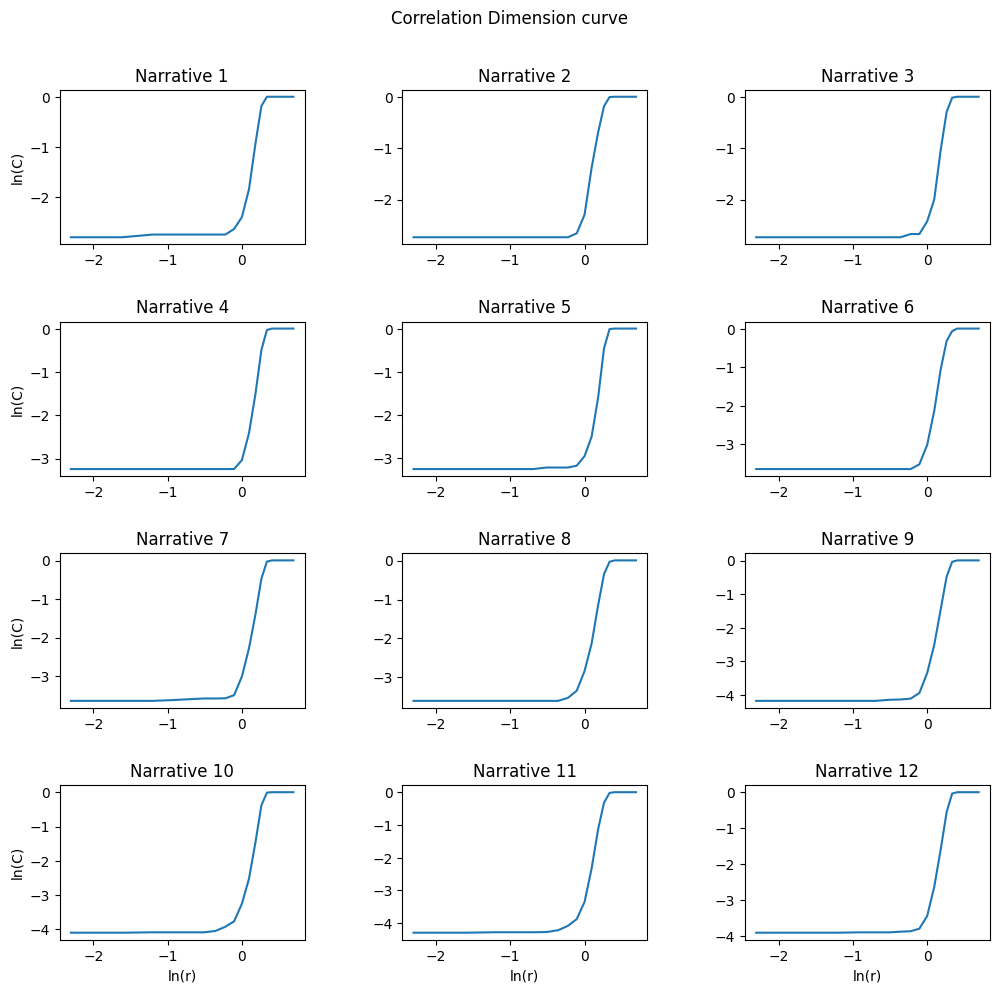

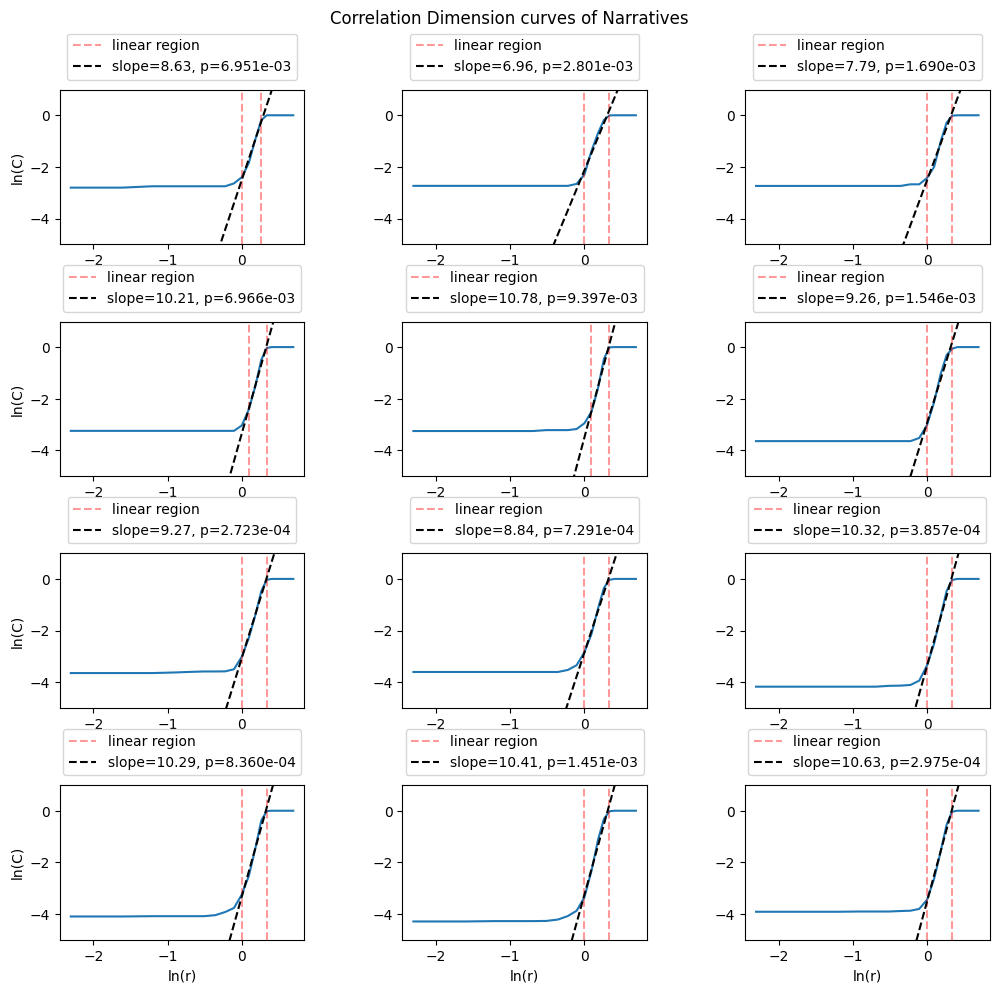

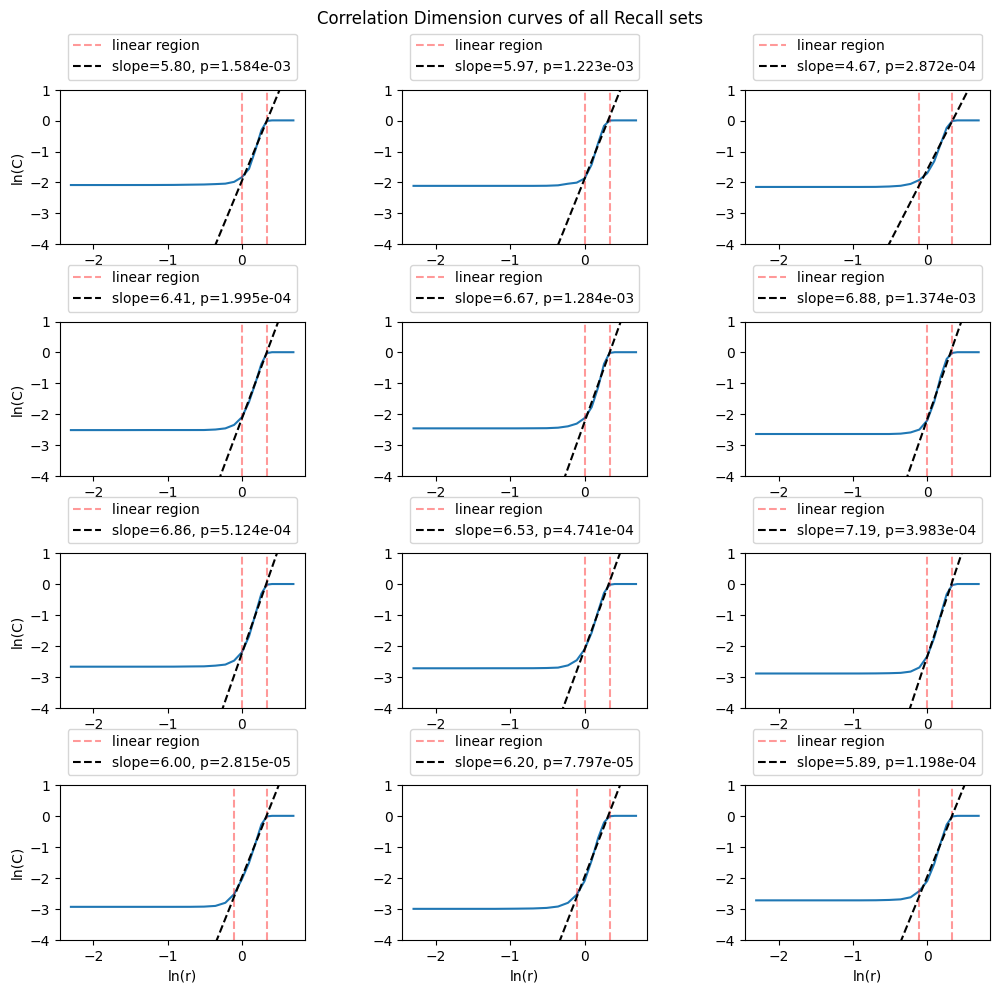

Narrative slopes: [8.629, 6.959, 7.79, 10.21, 10.776, 9.262, 9.275, 8.842, 10.325, 10.288, 10.412, 10.628]
Recall slopes:    [5.799, 5.974, 4.675, 6.406, 6.665, 6.884, 6.861, 6.531, 7.192, 5.999, 6.201, 5.888]


In [12]:
print("Bootstrap sampling to 250 points per story/participant.")
story_emb_all_boot  = [np.array(random.choices(story_emb_all[i], k=250)) for i in range(12)]
recall_emb_all_boot = [
    [np.array(random.choices(recall_emb_all[i][p], k=250))
     for p in range(len(recall_emb_all[i]))]
    for i in range(12)
]

print("Computing distance matrices.")
story_distance  = [euclidean_distance_matrix(story_emb_all_boot[i]) for i in range(12)]
recall_distance = [[euclidean_distance_matrix(p) for p in story] for story in recall_emb_all_boot]

print("Computing ln(C) ~ ln(r) curves.")
correlation_r        = np.linspace(0.1, 2, 20)
log_r                = [np.log(v) for v in correlation_r]
log_C_narratives_all = [nonlinear_dimension_data(story_distance[i]) for i in range(12)]

def process_participant(data):
    return nonlinear_dimension_data(data)

log_C_recall_all = []
for story in range(12):
    valid   = [p for p in range(len(recall_distance[story])) if len(recall_distance[story][p]) > 1]
    results = Parallel(n_jobs=-1)(
        delayed(process_participant)(recall_distance[story][p])
        for p in tqdm(valid, desc=f"Story {story+1}")
    )
    log_C_recall_all.append(results)

log_C_recall_mean = [np.mean(log_C_recall_all[i], axis=0) for i in range(12)]
print("Curves done.")

# ── ln(C) vs ln(r) preview ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle("Correlation Dimension curve")
axes = axes.flatten()
plt.subplots_adjust(top=0.90, bottom=0.05, hspace=0.5, wspace=0.4)
for i in range(12):
    axes[i].plot(log_r, log_C_narratives_all[i])
    axes[i].set_title(f"Narrative {i+1}")
    if i >= 9:    axes[i].set_xlabel("ln(r)")
    if i % 3 == 0: axes[i].set_ylabel("ln(C)")
plt.show()

# ── fit linear region — narratives ────────────────────────────────────────────
start_idx_narr, end_idx_narr = zip(*[find_linear_region(log_C_narratives_all[i]) for i in range(12)])
start_idx_rec,  end_idx_rec  = zip(*[find_linear_region(log_C_recall_mean[i])    for i in range(12)])

x_reg = np.linspace(np.min(log_r), np.max(log_r), 50)

fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle("Correlation Dimension curves of Narratives")
axes = axes.flatten()
plt.subplots_adjust(top=0.90, bottom=0.05, hspace=0.5, wspace=0.4)

narrative_slope = []
for i in range(12):
    s, e = start_idx_narr[i], end_idx_narr[i]
    ols  = sm.OLS(log_C_narratives_all[i][s:e+1],
                  sm.add_constant(log_r[s:e+1])).fit()
    intercept, slope = ols.params
    narrative_slope.append(slope)

    axes[i].plot(log_r, log_C_narratives_all[i])
    axes[i].axvline(log_r[s], ls='--', color='red', alpha=0.4, label='linear region')
    axes[i].axvline(log_r[e], ls='--', color='red', alpha=0.4)
    axes[i].plot(x_reg, intercept + slope * x_reg, '--', color='black',
                 label=f"slope={slope:.2f}, p={ols.pvalues[1]:.3e}")
    axes[i].set_ylim([-5, 1])
    axes[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02))
    if i >= 9:    axes[i].set_xlabel("ln(r)")
    if i % 3 == 0: axes[i].set_ylabel("ln(C)")
plt.show()

# ── fit linear region — recalls ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle("Correlation Dimension curves of all Recall sets")
axes = axes.flatten()
plt.subplots_adjust(top=0.90, bottom=0.05, hspace=0.5, wspace=0.4)

recall_slope = []
for i in range(12):
    s, e = start_idx_rec[i], end_idx_rec[i]
    ols  = sm.OLS(log_C_recall_mean[i][s:e+1],
                  sm.add_constant(log_r[s:e+1])).fit()
    intercept, slope = ols.params
    recall_slope.append(slope)

    axes[i].plot(log_r, log_C_recall_mean[i])
    axes[i].axvline(log_r[s], ls='--', color='red', alpha=0.4, label='linear region')
    axes[i].axvline(log_r[e], ls='--', color='red', alpha=0.4)
    axes[i].plot(x_reg, intercept + slope * x_reg, '--', color='black',
                 label=f"slope={slope:.2f}, p={ols.pvalues[1]:.3e}")
    axes[i].set_ylim([-4, 1])
    axes[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02))
    if i >= 9:    axes[i].set_xlabel("ln(r)")
    if i % 3 == 0: axes[i].set_ylabel("ln(C)")
plt.show()

print("Narrative slopes:", [round(s, 3) for s in narrative_slope])
print("Recall slopes:   ", [round(s, 3) for s in recall_slope])


In [13]:
## get the bootstrap result. -- actually no bootstrap here..
bootstrap_slope_narrative_data = narrative_slope
bootstrap_slope_recall_data    = recall_slope

## compression ratio for plot.
clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
clause_recall = [9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]
compression_ratio = [item1/item2 for item1, item2 in zip(clause_recall, clause_story)]

## normalize
bootstrap_slope_narrative_normalized = [item1/item2 for item1, item2 in zip(bootstrap_slope_narrative_data, clause_story)]
bootstrap_slope_recall_normalized = [item1/item2 for item1, item2 in zip(bootstrap_slope_recall_data, clause_recall)]

print("nonlinear dim:", bootstrap_slope_narrative_data)
print("max # clauses:", clause_story)

nonlinear dim: [8.629096504969338, 6.9590301565189225, 7.790105824120436, 10.210027101289068, 10.776188211035189, 9.262033934402458, 9.274959634919107, 8.841872627545381, 10.324722971472925, 10.288418003642875, 10.411634423845756, 10.628285310169339]
max # clauses: [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


p = 4.2300e-07,  R² = 0.930

  Bootstrap results (n_boot=10,000, n=12)
  r:     mean=0.9661, 95% CI=[0.9297, 0.9928]
         p = 0.0000  ***
  slope: mean=1.03891, 95% CI=[0.86711, 1.23145]
         p = 0.0000  ***
  R²:    mean=0.9336, 95% CI=[0.8643, 0.9857]
  power: mean=1.0000, 95% CI=[1.0000, 1.0000]


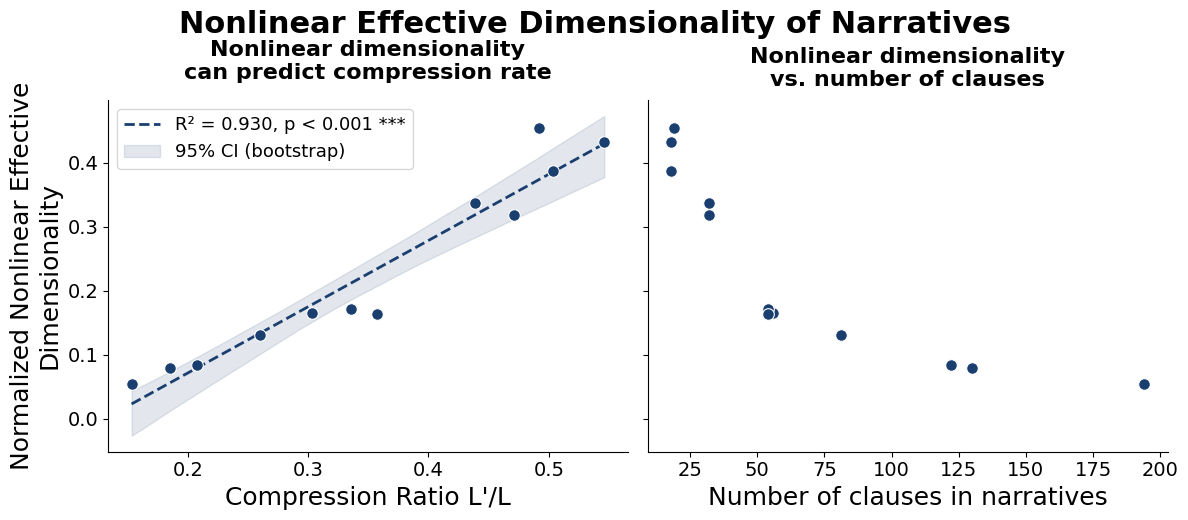

In [14]:
from scipy.interpolate import PchipInterpolator
from collections import defaultdict
from scipy.optimize import curve_fit
from scipy.stats import t as sp_t, nct as sp_nct
from scipy import stats as sp_stats

dot_color  = '#1a3f6f'
line_color = '#1a3f6f'

y     = bootstrap_slope_narrative_normalized
x_arr = np.array(compression_ratio)
y_arr = np.array(y)
n     = len(x_arr)

# ── OLS regression ────────────────────────────────────────────────────────────
X2      = sm.add_constant(x_arr)
model2  = sm.OLS(y_arr, X2).fit()
intercept2, slope2 = model2.params
p2, r2_2 = model2.pvalues[1], model2.rsquared
print(f"p = {p2:.4e},  R² = {r2_2:.3f}")

x_reg2 = np.linspace(x_arr.min(), x_arr.max(), 300)
y_line = intercept2 + slope2 * x_reg2

# ── bootstrap ─────────────────────────────────────────────────────────────────
n_boot = 10000
slope_boot, intercept_boot, r_boot, power_boot = [], [], [], []

for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    if len(np.unique(idx)) < 2:
        continue
    sl, ic, r_i, *_ = sp_stats.linregress(x_arr[idx], y_arr[idx])
    slope_boot.append(sl)
    intercept_boot.append(ic)
    r_boot.append(r_i)
    ncp_i  = r_i * np.sqrt(n) / np.sqrt(max(1 - r_i**2, 1e-10))
    t_crit = sp_t.ppf(0.975, n - 2)
    power_boot.append(1 - sp_nct.cdf(t_crit, n-2, ncp_i) +
                          sp_nct.cdf(-t_crit, n-2, ncp_i))

slope_boot     = np.array(slope_boot)
intercept_boot = np.array(intercept_boot)
r_boot         = np.array(r_boot)
power_boot     = np.array(power_boot)

y_boot_lines = np.array([intercept_boot[j] + slope_boot[j] * x_reg2
                          for j in range(len(slope_boot))])
boot_ci_low  = np.percentile(y_boot_lines,  2.5, axis=0)
boot_ci_high = np.percentile(y_boot_lines, 97.5, axis=0)

p_boot  = 2 * min(np.mean(r_boot <= 0), np.mean(r_boot >= 0))
p_slope = 2 * min(np.mean(slope_boot <= 0), np.mean(slope_boot >= 0))

def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

print(f"\n{'='*55}")
print(f"  Bootstrap results (n_boot={n_boot:,}, n={n})")
print(f"{'='*55}")
print(f"  r:     mean={r_boot.mean():.4f}, 95% CI=[{np.percentile(r_boot,2.5):.4f}, {np.percentile(r_boot,97.5):.4f}]")
print(f"         p = {p_boot:.4f}  {sig(p_boot)}")
print(f"  slope: mean={slope_boot.mean():.5f}, 95% CI=[{np.percentile(slope_boot,2.5):.5f}, {np.percentile(slope_boot,97.5):.5f}]")
print(f"         p = {p_slope:.4f}  {sig(p_slope)}")
print(f"  R²:    mean={(r_boot**2).mean():.4f}, 95% CI=[{np.percentile(r_boot**2,2.5):.4f}, {np.percentile(r_boot**2,97.5):.4f}]")
print(f"  power: mean={power_boot.mean():.4f}, 95% CI=[{np.percentile(power_boot,2.5):.4f}, {np.percentile(power_boot,97.5):.4f}]")
print(f"{'='*55}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ── left panel ────────────────────────────────────────────────────────────────
ax1.scatter(x_arr, y_arr, color=dot_color, s=70, zorder=3,
            edgecolors='white', linewidths=0.8)
ax1.plot(x_reg2, y_line, "--", color=line_color, lw=2,
         label=f"R² = {r2_2:.3f}, p < 0.001 ***")
ax1.fill_between(x_reg2, boot_ci_low, boot_ci_high,
                 color=line_color, alpha=0.12, label='95% CI (bootstrap)')
ax1.set_xlabel("Compression Ratio L'/L", fontsize=18)
ax1.set_ylabel("Normalized Nonlinear Effective\nDimensionality", fontsize=18)
ax1.set_title("Nonlinear dimensionality\ncan predict compression rate",
              fontsize=16, fontweight='bold', pad=15)
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=13)
ax1.spines[['top', 'right']].set_visible(False)

# ── right panel ───────────────────────────────────────────────────────────────
ax2.scatter(clause_story, bootstrap_slope_narrative_normalized,
            color=dot_color, s=70, zorder=3, edgecolors='white', linewidths=0.8)
ax2.set_xlabel("Number of clauses in narratives", fontsize=18)
ax2.set_ylabel("")
ax2.set_title("Nonlinear dimensionality\nvs. number of clauses",
              fontsize=16, fontweight='bold', pad=10)
ax2.tick_params(labelsize=14)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle("Nonlinear Effective Dimensionality of Narratives",
             fontsize=22, fontweight='bold', y=1.03)
plt.show()


In [15]:
## leave-one-out result.
# ── leave-one-out analysis ────────────────────────────────────────────────────
loo_slopes, loo_intercepts, loo_r, loo_p = [], [], [], []

for i in range(n):
    mask   = np.ones(n, dtype=bool)
    mask[i] = False
    sl, ic, r_i, p_i, _ = sp_stats.linregress(x_arr[mask], y_arr[mask])
    loo_slopes.append(sl)
    loo_intercepts.append(ic)
    loo_r.append(r_i)
    loo_p.append(p_i)

loo_slopes      = np.array(loo_slopes)
loo_r           = np.array(loo_r)
loo_p           = np.array(loo_p)
all_sig         = np.all(loo_p < 0.05)

print(f"\n{'='*60}")
print(f"  Leave-One-Out Analysis (n={n})")
print(f"{'='*60}")
print(f"  {'Left out':>8}  {'slope':>8}  {'r':>7}  {'R²':>6}  {'p':>10}  sig")
print(f"  {'-'*55}")
for i in range(n):
    s = sig(loo_p[i])
    print(f"  {i+1:>8}  {loo_slopes[i]:>8.5f}  {loo_r[i]:>7.4f}  "
          f"{loo_r[i]**2:>6.4f}  {loo_p[i]:>10.4e}  {s}")
print(f"  {'-'*55}")
print(f"  slope range: [{loo_slopes.min():.5f}, {loo_slopes.max():.5f}]")
print(f"  r     range: [{loo_r.min():.4f}, {loo_r.max():.4f}]")
print(f"  R²    range: [{(loo_r**2).min():.4f}, {(loo_r**2).max():.4f}]")
print(f"  all p < 0.05: {all_sig}")
print(f"{'='*60}")



  Leave-One-Out Analysis (n=12)
  Left out     slope        r      R²           p  sig
  -------------------------------------------------------
         1   0.96888   0.9763  0.9532  2.7317e-07  ***
         2   1.03536   0.9598  0.9212  2.8956e-06  ***
         3   1.03208   0.9559  0.9137  4.3687e-06  ***
         4   1.05823   0.9661  0.9333  1.3619e-06  ***
         5   1.02712   0.9633  0.9279  1.9326e-06  ***
         6   1.03197   0.9641  0.9294  1.7537e-06  ***
         7   1.03153   0.9679  0.9368  1.0640e-06  ***
         8   1.03669   0.9760  0.9526  2.9019e-07  ***
         9   1.06023   0.9617  0.9248  2.3442e-06  ***
        10   1.04030   0.9604  0.9223  2.7120e-06  ***
        11   1.07816   0.9615  0.9244  2.3941e-06  ***
        12   1.03433   0.9626  0.9267  2.0906e-06  ***
  -------------------------------------------------------
  slope range: [0.96888, 1.07816]
  r     range: [0.9559, 0.9763]
  R²    range: [0.9137, 0.9532]
  all p < 0.05: True


In [16]:
## statistical report.
from scipy import stats as sp_stats

x = np.array(compression_ratio)
y_arr = np.array(y)
n = len(x)

# ── OLS stats ──
r_p, p_pearson = sp_stats.pearsonr(x, y_arr)
r2     = r_p**2
df     = n - 2
t_obs  = r_p * np.sqrt(df) / np.sqrt(1 - r_p**2)
t_crit = sp_stats.t.ppf(0.975, df)
power  = 1 - sp_stats.t.cdf(t_crit, df, loc=t_obs) + sp_stats.t.cdf(-t_crit, df, loc=t_obs)
cohen_f2 = r2 / (1 - r2)

z_r     = np.arctanh(r_p)
se_z    = 1 / np.sqrt(n - 3)
ci_low  = np.tanh(z_r - 1.96 * se_z)
ci_high = np.tanh(z_r + 1.96 * se_z)

print("=" * 52)
print(f"  n = {n}")
print(f"  slope      = {slope2:.4f}  (SE={model2.bse[1]:.4f})")
print(f"  intercept  = {intercept2:.4f}")
print(f"  t({df})     = {t_obs:.4f}")
print(f"  Pearson r  = {r_p:.4f}  (p={p_pearson:.4f})")
print(f"  R²         = {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  Cohen's f² = {cohen_f2:.4f}  ({'small' if cohen_f2<0.15 else 'medium' if cohen_f2<0.35 else 'large'})")
print(f"  Fisher CI  = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  Power      = {power:.4f}  (α=0.05, parametric)")

# ── permutation test ──
n_perm  = 10000
r_perm  = np.array([sp_stats.pearsonr(np.random.permutation(x), y_arr)[0]
                    for _ in range(n_perm)])
p_perm  = np.mean(np.abs(r_perm) >= np.abs(r_p))
print(f"\n  Permutation p (n={n_perm}) = {p_perm:.4f}")

# ── bootstrap CI ──
from scipy.stats import nct as sp_nct, t as sp_t

def bootstrap_power(r, n, alpha=0.05):
    if abs(r) >= 1:
        return 1.0
    df  = n - 2
    ncp = r * np.sqrt(n) / np.sqrt(1 - r**2)
    t_crit = sp_t.ppf(1 - alpha / 2, df)
    return 1 - sp_nct.cdf(t_crit, df, ncp) + sp_nct.cdf(-t_crit, df, ncp)

n_boot = 10000
r_boot, slope_boot, r2_boot, power_boot = [], [], [], []

for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    if len(np.unique(x[idx])) < 2:
        continue
    r_i  = sp_stats.pearsonr(x[idx], y_arr[idx])[0]
    sl_i, *_ = sp_stats.linregress(x[idx], y_arr[idx])
    r_boot.append(r_i)
    slope_boot.append(sl_i)
    r2_boot.append(r_i ** 2)
    power_boot.append(bootstrap_power(r_i, n))

r_boot     = np.array(r_boot)
slope_boot = np.array(slope_boot)
r2_boot    = np.array(r2_boot)
power_boot = np.array(power_boot)

ci_low_b   = np.percentile(r_boot,     2.5);  ci_high_b   = np.percentile(r_boot,     97.5)
ci_sl_low  = np.percentile(slope_boot, 2.5);  ci_sl_high  = np.percentile(slope_boot, 97.5)
ci_r2_low  = np.percentile(r2_boot,   2.5);  ci_r2_high  = np.percentile(r2_boot,   97.5)
ci_pw_low  = np.percentile(power_boot, 2.5);  ci_pw_high  = np.percentile(power_boot, 97.5)
p_boot     = 2 * min(np.mean(r_boot     <= 0), np.mean(r_boot     >= 0))
p_slope    = 2 * min(np.mean(slope_boot <= 0), np.mean(slope_boot >= 0))

sig    = ('***' if p_boot  < 0.001 else '**' if p_boot  < 0.01 else '*' if p_boot  < 0.05 else 'ns')
sig_sl = ('***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns')

print("=" * 56)
print(f"  Bootstrap results (n_boot = {n_boot:,}, n = {n})")
print("=" * 56)
print(f"  r:     mean={np.mean(r_boot):.4f}, median={np.median(r_boot):.4f}, SD={np.std(r_boot):.4f}")
print(f"         95% CI = [{ci_low_b:.4f}, {ci_high_b:.4f}],  p = {p_boot:.4f} {sig}")
print(f"  slope: mean={np.mean(slope_boot):.4f}, median={np.median(slope_boot):.4f}, SD={np.std(slope_boot):.4f}")
print(f"         95% CI = [{ci_sl_low:.4f}, {ci_sl_high:.4f}],  p = {p_slope:.4f} {sig_sl}")
print(f"  R²:    mean={np.mean(r2_boot):.4f}, median={np.median(r2_boot):.4f}")
print(f"         95% CI = [{ci_r2_low:.4f}, {ci_r2_high:.4f}]")
print(f"  power: mean={np.mean(power_boot):.4f}, median={np.median(power_boot):.4f}")
print(f"         95% CI = [{ci_pw_low:.4f}, {ci_pw_high:.4f}]")
print("=" * 56)


  n = 12
  slope      = 1.0356  (SE=0.0898)
  intercept  = -0.1355
  t(10)     = 11.5358
  Pearson r  = 0.9644  (p=0.0000)
  R²         = 0.9301  (93.0% variance explained)
  Cohen's f² = 13.3075  (large)
  Fisher CI  = [0.8746, 0.9902]
  Power      = 1.0000  (α=0.05, parametric)

  Permutation p (n=10000) = 0.0000
  Bootstrap results (n_boot = 10,000, n = 12)
  r:     mean=0.9660, median=0.9675, SD=0.0164
         95% CI = [0.9301, 0.9929],  p = 0.0000 ***
  slope: mean=1.0399, median=1.0359, SD=0.0913
         95% CI = [0.8709, 1.2334],  p = 0.0000 ***
  R²:    mean=0.9334, median=0.9361
         95% CI = [0.8650, 0.9858]
  power: mean=1.0000, median=1.0000
         95% CI = [1.0000, 1.0000]


### OLS regression on both L and L'

In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as sp_stats

clause_story = np.array(
    [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81], dtype=float
)  # L
clause_recall = np.array(
    [9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05],
    dtype=float
)  # L'

y = np.array(bootstrap_slope_narrative_normalized, dtype=float)
n = len(y)
assert len(clause_story) == n and len(clause_recall) == n, "Length mismatch between predictors and y"

predictor_names = ["clause_story (L)", "clause_recall (L')"]
X = np.column_stack([clause_story, clause_recall])
X_design = sm.add_constant(X)

# ── OLS multiple regression ──────────────────────────────────────────────
model = sm.OLS(y, X_design).fit()
print(model.summary(xname=["const"] + predictor_names))

# ── Multicollinearity check (L and L' are likely correlated) ────────────
corr_L_Lp, corr_p = sp_stats.pearsonr(clause_story, clause_recall)
vif_values = [variance_inflation_factor(X_design, i) for i in range(X_design.shape[1])]

print(f"\nPearson r(L, L') = {corr_L_Lp:.4f}, p = {corr_p:.4f}")
print("VIF (>5–10 signals problematic collinearity):")
for name, vif in zip(["const"] + predictor_names, vif_values):
    print(f"  {name}: {vif:.3f}")

# ── Standardized (beta) coefficients — comparable effect sizes despite different scales ──
X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
y_std = (y - y.mean()) / y.std(ddof=1)
model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()

print("\nStandardized (beta) coefficients:")
for name, beta in zip(["const"] + predictor_names, model_std.params):
    print(f"  {name}: {beta:.4f}")



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     35.45
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           5.40e-05
Time:                        21:49:44   Log-Likelihood:                 18.345
No. Observations:                  12   AIC:                            -30.69
Df Residuals:                       9   BIC:                            -29.24
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7851      0

## Max likelihood estimate for nonlinear dimension.

In [19]:
from sklearn.neighbors import NearestNeighbors

# ── Levina & Bickel (2004) MLE intrinsic dimensionality ──────────────────────
def mle_intrinsic_dim(X, k=10, eps=1e-10):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    if k < 2 or k >= n:
        raise ValueError(f"k must satisfy 2 <= k < {n}")
    nbrs    = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X)
    dist, _ = nbrs.kneighbors(X)
    D       = np.maximum(dist[:, 1:k+1], eps)
    T_k     = D[:, -1]
    logs    = np.log(T_k[:, None] / D[:, :k-1])
    m_i     = 1.0 / np.mean(logs, axis=1)
    m_i[~np.isfinite(m_i)] = np.nan
    return float(np.nanmean(m_i))

# use original embeddings directly — no bootstrap needed for MLE
mle_id_narrative = []
for i in range(12):
    X = np.array(story_emb_all[i])          # shape (n_clauses, 384)
    k = min(10, len(X) - 1)
    d = mle_intrinsic_dim(X, k=k)
    mle_id_narrative.append(d)
    print(f"  Narrative {i+1}: n_clauses={len(X)}, MLE dim = {d:.3f}")

mle_id_recall = []
for i in range(12):
    dims = []
    for p in range(len(recall_emb_all[i])):
        X = np.array(recall_emb_all[i][p])
        if len(X) < 3:
            continue
        k = min(10, len(X) - 1)
        dims.append(mle_intrinsic_dim(X, k=k))
    mle_id_recall.append(float(np.mean(dims)) if dims else np.nan)
    print(f"  Recall  {i+1}: MLE dim = {mle_id_recall[-1]:.3f}")


  Narrative 1: n_clauses=19, MLE dim = 14.819
  Narrative 2: n_clauses=18, MLE dim = 16.581
  Narrative 3: n_clauses=18, MLE dim = 14.727
  Narrative 4: n_clauses=32, MLE dim = 20.260
  Narrative 5: n_clauses=32, MLE dim = 19.936
  Narrative 6: n_clauses=56, MLE dim = 18.488
  Narrative 7: n_clauses=54, MLE dim = 15.643
  Narrative 8: n_clauses=54, MLE dim = 15.593
  Narrative 9: n_clauses=130, MLE dim = 18.367
  Narrative 10: n_clauses=122, MLE dim = 18.707
  Narrative 11: n_clauses=194, MLE dim = 18.167
  Narrative 12: n_clauses=81, MLE dim = 20.217
  Recall  1: MLE dim = 12.737
  Recall  2: MLE dim = 12.957
  Recall  3: MLE dim = 11.003
  Recall  4: MLE dim = 13.093
  Recall  5: MLE dim = 13.849
  Recall  6: MLE dim = 14.402
  Recall  7: MLE dim = 13.948
  Recall  8: MLE dim = 12.570
  Recall  9: MLE dim = 14.257
  Recall  10: MLE dim = 13.577
  Recall  11: MLE dim = 14.585
  Recall  12: MLE dim = 15.071



MLE intrinsic dim (narratives): [14.819, 16.581, 14.727, 20.26, 19.936, 18.488, 15.643, 15.593, 18.367, 18.707, 18.167, 20.217]
Normalized by clause count:     [0.78, 0.9211, 0.8182, 0.6331, 0.623, 0.3302, 0.2897, 0.2888, 0.1413, 0.1533, 0.0936, 0.2496]
Compression ratio regression:  R² = 0.915,  p = 1.1235e-06


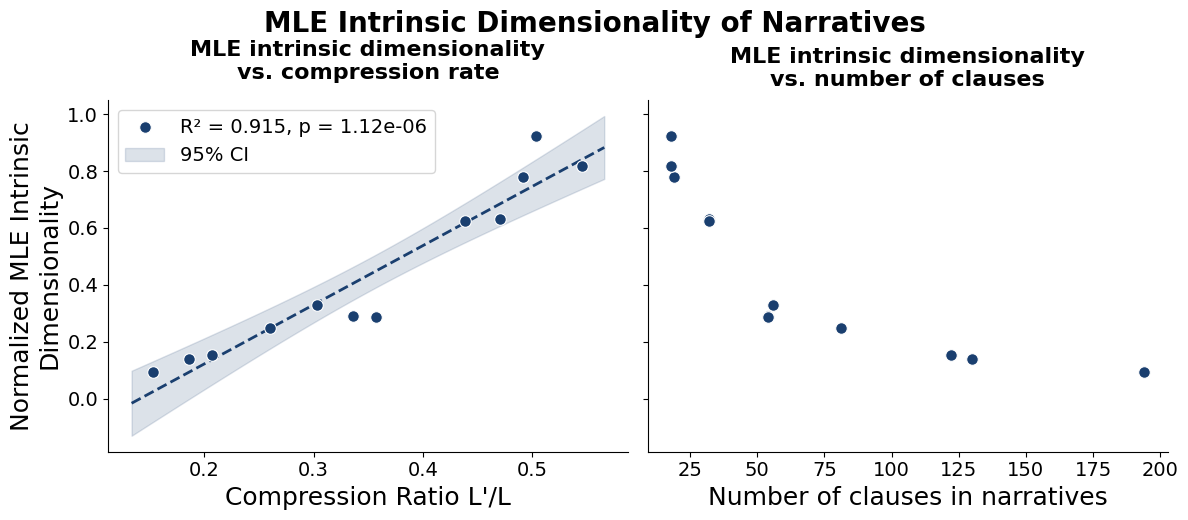

In [20]:
# ── downstream: normalization + plot (same as before) ────────────────────────
clause_story  = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
clause_recall = [9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]
compression_ratio = [r/s for r, s in zip(clause_recall, clause_story)]

narrative_normalized = [d/s for d, s in zip(mle_id_narrative, clause_story)]
recall_normalized    = [d/r for d, r in zip(mle_id_recall,    clause_recall)]

print("\nMLE intrinsic dim (narratives):", [round(d, 3) for d in mle_id_narrative])
print("Normalized by clause count:    ", [round(d, 4) for d in narrative_normalized])

dot_color = line_color = '#1a3f6f'

y    = narrative_normalized
X2   = sm.add_constant(compression_ratio)
ols2 = sm.OLS(y, X2).fit()
intercept2, slope2 = ols2.params
p2, r2_2 = ols2.pvalues[1], ols2.rsquared
print(f"Compression ratio regression:  R² = {r2_2:.3f},  p = {p2:.4e}")

x_reg2   = np.linspace(min(compression_ratio)-0.02, max(compression_ratio)+0.02, 300)
pred_df2 = ols2.get_prediction(sm.add_constant(x_reg2)).summary_frame(alpha=0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.scatter(compression_ratio, y, color=dot_color, s=70, zorder=3,
            edgecolors='white', linewidths=0.8,
            label=f"R² = {r2_2:.3f}, p = {p2:.2e}")
ax1.plot(x_reg2, intercept2 + slope2 * x_reg2, '--', color=line_color, lw=2)
ax1.fill_between(x_reg2, pred_df2['mean_ci_lower'], pred_df2['mean_ci_upper'],
                 color=line_color, alpha=0.15, label='95% CI')
ax1.set_xlabel("Compression Ratio L'/L", fontsize=18)
ax1.set_ylabel("Normalized MLE Intrinsic\nDimensionality", fontsize=18)
ax1.set_title("MLE intrinsic dimensionality\nvs. compression rate",
              fontsize=16, fontweight='bold', pad=15)
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=14)
ax1.spines[['top', 'right']].set_visible(False)

ax2.scatter(clause_story, narrative_normalized, color=dot_color, s=70, zorder=3,
            edgecolors='white', linewidths=0.8)
ax2.set_xlabel("Number of clauses in narratives", fontsize=18)
ax2.set_title("MLE intrinsic dimensionality\nvs. number of clauses",
              fontsize=16, fontweight='bold', pad=10)
ax2.tick_params(labelsize=14)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle("MLE Intrinsic Dimensionality of Narratives",
             fontsize=20, fontweight='bold', y=1.03)
plt.show()


In [21]:
from scipy.stats import nct as sp_nct, t as sp_t, pearsonr
import statsmodels.api as sm
import numpy as np

x_arr = np.array(compression_ratio)
y_arr = np.array(y)
n     = len(x_arr)

# ── OLS regression ────────────────────────────────────────────────────────────
X2   = sm.add_constant(x_arr)
ols2 = sm.OLS(y_arr, X2).fit()
intercept2, slope2 = ols2.params
p2, r2_2 = ols2.pvalues[1], ols2.rsquared
se_slope  = ols2.bse[1]
ci_slope  = ols2.conf_int(alpha=0.05)[1]
r_pearson, p_pearson = pearsonr(x_arr, y_arr)

# ── permutation test ──────────────────────────────────────────────────────────
n_perm   = 10000
r_obs    = r_pearson
perm_r   = [pearsonr(np.random.permutation(x_arr), y_arr)[0] for _ in range(n_perm)]
p_perm   = np.mean(np.abs(perm_r) >= np.abs(r_obs))

# ── bootstrap ─────────────────────────────────────────────────────────────────
n_boot = 10000
r_boot, slope_boot, r2_boot, power_boot = [], [], [], []

for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    if len(np.unique(idx)) < 2:
        continue
    r_i  = pearsonr(x_arr[idx], y_arr[idx])[0]
    sl_i = np.polyfit(x_arr[idx], y_arr[idx], 1)[0]
    r_boot.append(r_i)
    slope_boot.append(sl_i)
    r2_boot.append(r_i ** 2)
    df_i  = n - 2
    ncp_i = r_i * np.sqrt(n) / np.sqrt(max(1 - r_i**2, 1e-10))
    t_c   = sp_t.ppf(0.975, df_i)
    power_boot.append(1 - sp_nct.cdf(t_c, df_i, ncp_i) + sp_nct.cdf(-t_c, df_i, ncp_i))

r_boot     = np.array(r_boot)
slope_boot = np.array(slope_boot)
r2_boot    = np.array(r2_boot)
power_boot = np.array(power_boot)

p_boot  = 2 * min(np.mean(r_boot <= 0), np.mean(r_boot >= 0))
p_sl    = 2 * min(np.mean(slope_boot <= 0), np.mean(slope_boot >= 0))

def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

# ── report ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Compression Ratio → Normalized MLE Intrinsic Dim")
print("=" * 60)
print(f"  n                        = {n}")
print()
print(f"  [OLS Regression]")
print(f"  slope                    = {slope2:.5f}")
print(f"  slope SE                 = {se_slope:.5f}")
print(f"  slope 95% CI             = [{ci_slope[0]:.5f}, {ci_slope[1]:.5f}]")
print(f"  intercept                = {intercept2:.5f}")
print(f"  R²                       = {r2_2:.4f}")
print(f"  p (parametric)           = {p2:.4e}  {sig(p2)}")
print()
print(f"  [Pearson r]")
print(f"  r                        = {r_pearson:.4f}")
print(f"  p (parametric)           = {p_pearson:.4e}  {sig(p_pearson)}")
print()
print(f"  [Permutation test]  (n={n_perm:,})")
print(f"  p (permutation)          = {p_perm:.4f}  {sig(p_perm)}")
print()
print(f"  [Bootstrap]  (n={n_boot:,})")
print(f"  r:     mean={np.mean(r_boot):.4f}, SD={np.std(r_boot):.4f}")
print(f"         95% CI = [{np.percentile(r_boot,2.5):.4f}, {np.percentile(r_boot,97.5):.4f}]")
print(f"         p      = {p_boot:.4f}  {sig(p_boot)}")
print(f"  slope: mean={np.mean(slope_boot):.5f}, SD={np.std(slope_boot):.5f}")
print(f"         95% CI = [{np.percentile(slope_boot,2.5):.5f}, {np.percentile(slope_boot,97.5):.5f}]")
print(f"         p      = {p_sl:.4f}  {sig(p_sl)}")
print(f"  R²:    mean={np.mean(r2_boot):.4f}")
print(f"         95% CI = [{np.percentile(r2_boot,2.5):.4f}, {np.percentile(r2_boot,97.5):.4f}]")
print(f"  power: mean={np.mean(power_boot):.4f}")
print(f"         95% CI = [{np.percentile(power_boot,2.5):.4f}, {np.percentile(power_boot,97.5):.4f}]")
print("=" * 60)


  Compression Ratio → Normalized MLE Intrinsic Dim
  n                        = 12

  [OLS Regression]
  slope                    = 2.07467
  slope SE                 = 0.19978
  slope 95% CI             = [1.62953, 2.51981]
  intercept                = -0.29190
  R²                       = 0.9151
  p (parametric)           = 1.1235e-06  ***

  [Pearson r]
  r                        = 0.9566
  p (parametric)           = 1.1235e-06  ***

  [Permutation test]  (n=10,000)
  p (permutation)          = 0.0000  ***

  [Bootstrap]  (n=10,000)
  r:     mean=0.9586, SD=0.0193
         95% CI = [0.9171, 0.9916]
         p      = 0.0000  ***
  slope: mean=2.08398, SD=0.20248
         95% CI = [1.71566, 2.51250]
         p      = 0.0000  ***
  R²:    mean=0.9193
         95% CI = [0.8411, 0.9833]
  power: mean=1.0000
         95% CI = [1.0000, 1.0000]
